In [127]:
import pandas as pd
import numpy as np

In [129]:
df = pd.read_csv("caltech_full.csv")

In [ ]:


# # Convert time
# df["connectionTime"] = pd.to_datetime(df["connectionTime"])

# # Create hour timestamp
# df["hour_timestamp"] = df["connectionTime"].dt.floor("H")

# # Aggregate hourly demand
# hourly_sum = (
#     df.groupby(["stationID", "hour_timestamp"])["kWhDelivered"]
#       .sum()
#       .reset_index()
#       .rename(columns={"kWhDelivered": "total_kwh"})
# )

# # Create continuous hourly grid per station
# full_data = []

# for station in hourly_sum["stationID"].unique():

#     station_df = hourly_sum[hourly_sum["stationID"] == station]

#     full_range = pd.date_range(
#         start=station_df["hour_timestamp"].min(),
#         end=station_df["hour_timestamp"].max(),
#         freq="H"
#     )

#     full_station = pd.DataFrame({
#         "stationID": station,
#         "hour_timestamp": full_range
#     })

#     merged = full_station.merge(
#         station_df,
#         on=["stationID", "hour_timestamp"],
#         how="left"
#     )

#     merged["total_kwh"] = merged["total_kwh"].fillna(0)

#     full_data.append(merged)

# hourly_data = pd.concat(full_data, ignore_index=True)

/tmp/ipython-input-1014/70954663.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour_timestamp"] = df["connectionTime"].dt.floor("H")
/tmp/ipython-input-1014/70954663.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(
/tmp/ipython-input-1014/70954663.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(
/tmp/ipython-input-1014/70954663.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(
/tmp/ipython-input-1014/70954663.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_range = pd.date_range(
/tmp/ipython-input-1014/70954663.py:22: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' in

In [ ]:
# print("Zero ratio:",
#       (hourly_data["total_kwh"] == 0).mean())

Zero ratio: 0.95737561995831


In [ ]:
# hourly_data = hourly_data.sort_values(["stationID", "hour_timestamp"])

# hourly_data["lag_1"] = hourly_data.groupby("stationID")["total_kwh"].shift(1)
# hourly_data["lag_3"] = hourly_data.groupby("stationID")["total_kwh"].shift(3)
# hourly_data["lag_24"] = hourly_data.groupby("stationID")["total_kwh"].shift(24)

# hourly_data["rolling_6"] = (
#     hourly_data.groupby("stationID")["total_kwh"]
#     .rolling(6)
#     .mean()
#     .shift(1)
#     .reset_index(level=0, drop=True)
# )

In [ ]:
hourly_data["target_next_hour"] = (
    hourly_data.groupby("stationID")["total_kwh"].shift(-1)
)

hourly_model_df = hourly_data.dropna().copy()

In [ ]:
hourly_model_df["demand_occurrence"] = (
    hourly_model_df["target_next_hour"] > 0
).astype(int)

In [ ]:
hourly_model_df["hour"] = hourly_model_df["hour_timestamp"].dt.hour
hourly_model_df["day_of_week"] = hourly_model_df["hour_timestamp"].dt.dayofweek
hourly_model_df["month"] = hourly_model_df["hour_timestamp"].dt.month
hourly_model_df["is_weekend"] = (hourly_model_df["day_of_week"] >= 5).astype(int)

import numpy as np
hourly_model_df["hour_sin"] = np.sin(2*np.pi*hourly_model_df["hour"]/24)
hourly_model_df["hour_cos"] = np.cos(2*np.pi*hourly_model_df["hour"]/24)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
hourly_model_df["station_encoded"] = le.fit_transform(
    hourly_model_df["stationID"]
)

In [ ]:
forecast_features = [
    "station_encoded",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "lag_1",
    "lag_3",
    "lag_24",
    "rolling_6",
    "hour_sin",
    "hour_cos"
]

In [ ]:
hourly_model_df = hourly_model_df.sort_values("hour_timestamp")

split_index = int(len(hourly_model_df) * 0.8)

train_df = hourly_model_df.iloc[:split_index]
test_df  = hourly_model_df.iloc[split_index:]

X_train = train_df[forecast_features]
X_test  = test_df[forecast_features]

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf.fit(X_train, train_df["demand_occurrence"])

pred_occ = clf.predict(X_test)

print("Accuracy:",
      accuracy_score(test_df["demand_occurrence"], pred_occ))

print(classification_report(
      test_df["demand_occurrence"], pred_occ))

KeyboardInterrupt: 

In [ ]:
train_positive = train_df[train_df["target_next_hour"] > 0]
test_positive  = test_df[test_df["target_next_hour"] > 0]

X_train_pos = train_positive[forecast_features]
y_train_pos = train_positive["target_next_hour"]

X_test_pos = test_positive[forecast_features]
y_test_pos = test_positive["target_next_hour"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

reg_pos = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

reg_pos.fit(X_train_pos, y_train_pos)

pred_pos = reg_pos.predict(X_test_pos)

print("MAE:",
      mean_absolute_error(y_test_pos, pred_pos))

print("R2:",
      r2_score(y_test_pos, pred_pos))

MAE: 6.587572536734024
R2: 0.011462452951138458


In [ ]:
print(hourly_model_df["target_next_hour"].corr(hourly_model_df["lag_1"]))
print(hourly_model_df["target_next_hour"].corr(hourly_model_df["lag_24"]))

-0.009682593724451268
0.041149250296793685


In [ ]:
df["connectionTime"] = pd.to_datetime(df["connectionTime"])
df["date"] = df["connectionTime"].dt.date

daily_data = (
    df.groupby(["stationID", "date"])["kWhDelivered"]
      .sum()
      .reset_index()
      .rename(columns={"kWhDelivered": "daily_kwh"})
)

In [ ]:
daily_data = daily_data.sort_values(["stationID", "date"])

daily_data["lag_1"] = daily_data.groupby("stationID")["daily_kwh"].shift(1)
daily_data["lag_7"] = daily_data.groupby("stationID")["daily_kwh"].shift(7)

daily_data["rolling_7"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(7)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

In [ ]:
daily_data["target_next_day"] = (
    daily_data.groupby("stationID")["daily_kwh"].shift(-1)
)

daily_model_df = daily_data.dropna().copy()

In [ ]:
print(daily_model_df["target_next_day"].corr(daily_model_df["lag_1"]))
print(daily_model_df["target_next_day"].corr(daily_model_df["lag_7"]))

0.15733980372498366
0.1678709638559834


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_model_df["station_encoded"] = le.fit_transform(
    daily_model_df["stationID"]
)

features_daily = [
    "station_encoded",
    "lag_1",
    "lag_7",
    "rolling_7"
]

daily_model_df = daily_model_df.sort_values("date")

split_index = int(len(daily_model_df) * 0.8)

train_df = daily_model_df.iloc[:split_index]
test_df  = daily_model_df.iloc[split_index:]

X_train = train_df[features_daily]
X_test  = test_df[features_daily]

y_train = train_df["target_next_day"]
y_test  = test_df["target_next_day"]

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

reg_daily = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

reg_daily.fit(X_train, y_train)

pred_daily = reg_daily.predict(X_test)

print("Daily MAE:", mean_absolute_error(y_test, pred_daily))
print("Daily RMSE:", np.sqrt(((y_test - pred_daily)**2).mean()))
print("Daily R2:", r2_score(y_test, pred_daily))

Daily MAE: 8.93919621397792
Daily RMSE: 11.890321622078083
Daily R2: -0.07181713354088415


In [ ]:
station_avg = hourly_data.groupby("stationID")["total_kwh"].mean()

low_stations = station_avg[station_avg < 2].index
medium_stations = station_avg[(station_avg >= 2) & (station_avg < 5)].index
high_stations = station_avg[station_avg >= 5].index

In [ ]:
system_hourly = (
    hourly_data.groupby("hour_timestamp")["total_kwh"]
    .sum()
    .reset_index()
)

In [ ]:
y_train_log = np.log1p(y_train)

In [130]:
import pandas as pd
import numpy as np

# Aggregate total system demand per hour
system_hourly = (
    hourly_data.groupby("hour_timestamp")["total_kwh"]
    .sum()
    .reset_index()
)

system_hourly = system_hourly.sort_values("hour_timestamp")

In [131]:
system_hourly["hour"] = system_hourly["hour_timestamp"].dt.hour
system_hourly["day_of_week"] = system_hourly["hour_timestamp"].dt.dayofweek
system_hourly["month"] = system_hourly["hour_timestamp"].dt.month

system_hourly["hour_sin"] = np.sin(2*np.pi*system_hourly["hour"]/24)
system_hourly["hour_cos"] = np.cos(2*np.pi*system_hourly["hour"]/24)

In [132]:
system_hourly["lag_1"] = system_hourly["total_kwh"].shift(1)
system_hourly["lag_24"] = system_hourly["total_kwh"].shift(24)
system_hourly["rolling_24"] = system_hourly["total_kwh"].rolling(24).mean().shift(1)

system_hourly["target"] = system_hourly["total_kwh"].shift(-1)

system_model_df = system_hourly.dropna()

In [133]:
split = int(len(system_model_df) * 0.8)

train = system_model_df.iloc[:split]
test = system_model_df.iloc[split:]

features = [
    "lag_1", "lag_24", "rolling_24",
    "hour_sin", "hour_cos", "day_of_week", "month"
]

X_train = train[features]
X_test = test[features]

y_train = train["target"]
y_test = test["target"]

In [134]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("System MAE:", mean_absolute_error(y_test, pred))
print("System RMSE:", np.sqrt(((y_test - pred)**2).mean()))
print("System R2:", r2_score(y_test, pred))

System MAE: 11.686125629048275
System RMSE: 18.976678678427294
System R2: 0.3528168490380984


In [135]:
station_avg = hourly_data.groupby("stationID")["total_kwh"].mean()

quantiles = station_avg.quantile([0.33, 0.66])

def assign_cluster(x):
    if x <= quantiles[0.33]:
        return 0
    elif x <= quantiles[0.66]:
        return 1
    else:
        return 2

station_cluster_map = station_avg.apply(assign_cluster).to_dict()

hourly_data["cluster"] = hourly_data["stationID"].map(station_cluster_map)

In [136]:
station_avg = hourly_data.groupby("stationID")["total_kwh"].mean()

quantiles = station_avg.quantile([0.33, 0.66])

def assign_cluster(x):
    if x <= quantiles[0.33]:
        return 0
    elif x <= quantiles[0.66]:
        return 1
    else:
        return 2

station_cluster_map = station_avg.apply(assign_cluster).to_dict()

hourly_data["cluster"] = hourly_data["stationID"].map(station_cluster_map)

In [137]:
station_avg = hourly_data.groupby("stationID")["total_kwh"].mean()

quantiles = station_avg.quantile([0.33, 0.66])

def assign_cluster(x):
    if x <= quantiles[0.33]:
        return 0
    elif x <= quantiles[0.66]:
        return 1
    else:
        return 2

station_cluster_map = station_avg.apply(assign_cluster).to_dict()

hourly_data["cluster"] = hourly_data["stationID"].map(station_cluster_map)

In [138]:
daily_data = (
    hourly_data.groupby([
        "stationID",
        hourly_data["hour_timestamp"].dt.date
    ])["total_kwh"]
    .sum()
    .reset_index()
    .rename(columns={"hour_timestamp": "date", "total_kwh": "daily_kwh"})
)

daily_data = daily_data.sort_values(["stationID", "date"])

In [139]:
daily_data["lag_1"] = daily_data.groupby("stationID")["daily_kwh"].shift(1)
daily_data["lag_7"] = daily_data.groupby("stationID")["daily_kwh"].shift(7)
daily_data["rolling_7"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(7)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

daily_data["target"] = daily_data.groupby("stationID")["daily_kwh"].shift(-1)

daily_model_df = daily_data.dropna()

In [140]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_model_df["station_encoded"] = le.fit_transform(
    daily_model_df["stationID"]
)

/tmp/ipython-input-1014/621568359.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_model_df["station_encoded"] = le.fit_transform(


In [141]:
features = ["station_encoded", "lag_1", "lag_7", "rolling_7"]

split = int(len(daily_model_df) * 0.8)

train = daily_model_df.iloc[:split]
test = daily_model_df.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["target"]
y_test = test["target"]

model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Daily MAE:", mean_absolute_error(y_test, pred))
print("Daily R2:", r2_score(y_test, pred))

Daily MAE: 8.243560509529503
Daily R2: 0.04023738637976715


In [ ]:
# First, determine the number of categories qcut can actually form
temp_cut = pd.qcut(
    system_hourly["total_kwh"],
    q=3,
    duplicates='drop'
)

# Get the number of actual categories formed
num_actual_categories = len(temp_cut.cat.categories)

# Create labels dynamically based on the actual number of categories
dynamic_labels = list(range(num_actual_categories))

# Apply qcut with the dynamically generated labels
system_hourly["category"] = pd.qcut(
    system_hourly["total_kwh"],
    q=3,
    labels=dynamic_labels,
    duplicates='drop'
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

clf = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

clf.fit(X_train, train["category"])

pred = clf.predict(X_test)

print(classification_report(test["category"], pred))

KeyError: 'category'

# Task
The previous attempt to train an XGBoost Classifier failed because the `category` column was not present in the `train` and `test` dataframes used for classification. This happened because the `system_model_df` was created by dropping NaN values *before* the `category` column was added to `system_hourly`.

To resolve this, I'll perform the following actions:
1.  **Re-create `system_model_df`:** Ensure the `category` column is added to `system_hourly` before `system_model_df` is created by dropping NaN values.
2.  **Split Data for Classification:** Use the newly created `system_model_df` to define the training and testing sets (`train` and `test`), and their respective features (`X_train`, `X_test`) and target (`y_train`, `y_test`) for the classification task.
3.  **Train and Evaluate XGBoost Classifier:** Train an `XGBClassifier` using the prepared data and then print the `classification_report` to evaluate its performance.

This will directly address the `KeyError` and allow the evaluation of the classifier's performance in predicting demand categories.

The final goal is to train an XGBoost classifier to predict demand categories (low, medium, high, or the actual number of categories qcut produces) using hourly system data and evaluate its performance with a classification report.

## Prepare System Hourly Data

### Subtask:
Ensure the `system_hourly` DataFrame is correctly prepared with all necessary features, including time-based features, lagged values, and a target column, but without creating `system_model_df` yet.


**Reasoning**:
The subtask requires aggregating total system demand per hour and creating time-based features, lagged values, and a target column in the `system_hourly` DataFrame. The existing code cells already perform these operations up to the point of creating the `system_model_df`.



In [ ]:
import pandas as pd
import numpy as np

# Aggregate total system demand per hour
system_hourly = (
    hourly_data.groupby("hour_timestamp")["total_kwh"]
    .sum()
    .reset_index()
)

system_hourly = system_hourly.sort_values("hour_timestamp")

system_hourly["hour"] = system_hourly["hour_timestamp"].dt.hour
system_hourly["day_of_week"] = system_hourly["hour_timestamp"].dt.dayofweek
system_hourly["month"] = system_hourly["hour_timestamp"].dt.month

system_hourly["hour_sin"] = np.sin(2*np.pi*system_hourly["hour"]/24)
system_hourly["hour_cos"] = np.cos(2*np.pi*system_hourly["hour"]/24)

system_hourly["lag_1"] = system_hourly["total_kwh"].shift(1)
system_hourly["lag_24"] = system_hourly["total_kwh"].shift(24)
system_hourly["rolling_24"] = system_hourly["total_kwh"].rolling(24).mean().shift(1)

system_hourly["target"] = system_hourly["total_kwh"].shift(-1)


In [ ]:
import pandas as pd
import numpy as np

# Aggregate daily demand per station
daily_data = (
    hourly_data
    .groupby([
        "stationID",
        hourly_data["hour_timestamp"].dt.date
    ])["total_kwh"]
    .sum()
    .reset_index()
)

daily_data.columns = ["stationID", "date", "daily_kwh"]

daily_data["date"] = pd.to_datetime(daily_data["date"])
daily_data = daily_data.sort_values(["stationID", "date"])

In [ ]:
daily_data["day_of_week"] = daily_data["date"].dt.dayofweek
daily_data["month"] = daily_data["date"].dt.month
daily_data["is_weekend"] = (daily_data["day_of_week"] >= 5).astype(int)

In [ ]:
daily_data["lag_1"] = daily_data.groupby("stationID")["daily_kwh"].shift(1)
daily_data["lag_7"] = daily_data.groupby("stationID")["daily_kwh"].shift(7)
daily_data["lag_14"] = daily_data.groupby("stationID")["daily_kwh"].shift(14)

daily_data["rolling_7"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(7)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

daily_data["rolling_14"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(14)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

In [ ]:
daily_data["target_next_day"] = (
    daily_data.groupby("stationID")["daily_kwh"].shift(-1)
)

daily_model_df = daily_data.dropna().copy()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_model_df["station_encoded"] = le.fit_transform(
    daily_model_df["stationID"]
)

In [ ]:
features = [
    "station_encoded",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "day_of_week",
    "month",
    "is_weekend"
]

In [ ]:
daily_model_df = daily_model_df.sort_values("date")

split_index = int(len(daily_model_df) * 0.8)

train_df = daily_model_df.iloc[:split_index]
test_df  = daily_model_df.iloc[split_index:]

X_train = train_df[features]
X_test  = test_df[features]

y_train = train_df["target_next_day"]
y_test  = test_df["target_next_day"]

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Daily MAE:", mean_absolute_error(y_test, pred))
print("Daily RMSE:", np.sqrt(((y_test - pred)**2).mean()))
print("Daily R2:", r2_score(y_test, pred))

Daily MAE: 6.548756632585157
Daily RMSE: 9.564411308129554
Daily R2: 0.1275341975991383


In [ ]:
# Log transform target
y_train_log = np.log1p(y_train)

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

# Predict
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

print("Daily MAE:", mean_absolute_error(y_test, pred))
print("Daily RMSE:", np.sqrt(((y_test - pred)**2).mean()))
print("Daily R2:", r2_score(y_test, pred))

Daily MAE: 5.505638417190215
Daily RMSE: 9.816082534489292
Daily R2: 0.08101520198974521


In [ ]:
daily_model_df["trend_3"] = (
    daily_model_df["lag_1"] - daily_model_df["lag_7"]
)

daily_model_df["volatility_7"] = (
    daily_model_df.groupby("stationID")["daily_kwh"]
    .rolling(7)
    .std()
    .shift(1)
    .reset_index(level=0, drop=True)
)

daily_model_df = daily_model_df.dropna()

In [ ]:
features = [
    "station_encoded",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "trend_3",
    "volatility_7",
    "day_of_week",
    "month",
    "is_weekend"
]

In [ ]:
# Log transform target
y_train_log = np.log1p(y_train)

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

# Predict
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

print("Daily MAE:", mean_absolute_error(y_test, pred))
print("Daily RMSE:", np.sqrt(((y_test - pred)**2).mean()))
print("Daily R2:", r2_score(y_test, pred))

Daily MAE: 5.505638417190215
Daily RMSE: 9.816082534489292
Daily R2: 0.08101520198974521


In [ ]:
# Create comparison dataframe
comparison_df = pd.DataFrame({
    "Date": test_df["date"],
    "Station": test_df["stationID"],
    "Actual_kWh": y_test,
    "Predicted_kWh": pred
})

# Show first 10 predictions
comparison_df.head(10)

,Date,Station,Actual_kWh,Predicted_kWh
11825,2019-01-27,2-39-79-380,24.102,10.416822
965,2019-01-27,2-39-124-22,14.030,2.146273
5250,2019-01-27,2-39-130-564,0.000,0.296117
6931,2019-01-27,2-39-139-28,0.000,7.017139
12175,2019-01-27,2-39-79-381,24.076,4.841394
15848,2019-01-27,2-39-90-440,5.390,1.873624
277,2019-01-27,2-39-123-23,53.724,6.094575
627,2019-01-27,2-39-123-557,0.000,0.903039
3360,2019-01-27,2-39-127-561,0.000,0.339529
11124,2019-01-27,2-39-79-378,11.677,12.053232


In [ ]:
station_example = comparison_df[
    comparison_df["Station"] == comparison_df["Station"].iloc[0]
]

station_example.tail(5)

,Date,Station,Actual_kWh,Predicted_kWh
11892,2019-04-04,2-39-79-380,5.978,9.795951
11893,2019-04-05,2-39-79-380,13.743,1.945654
11894,2019-04-06,2-39-79-380,0.000,1.801099
11895,2019-04-07,2-39-79-380,3.122,10.504646
11896,2019-04-08,2-39-79-380,9.139,12.716846


In [ ]:
def predict_next_day(station_id):

    # Get latest available row for that station
    station_df = daily_model_df[
        daily_model_df["stationID"] == station_id
    ].sort_values("date")

    latest_row = station_df.iloc[-1]

    input_features = latest_row[features].values.reshape(1, -1)

    pred_log = model.predict(input_features)
    prediction = np.expm1(pred_log)[0]  # if using log model

    print("🔋 DAILY EV DEMAND FORECAST")
    print("--------------------------------")
    print("Station:", station_id)
    print("Last Known Date:", latest_row["date"])
    print("Predicted Next-Day Demand (kWh):", round(prediction, 2))

    return prediction

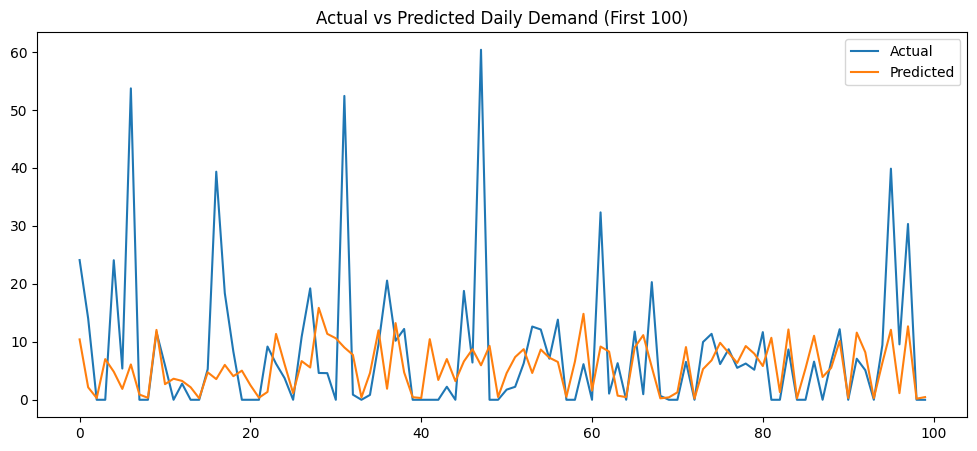

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Daily Demand (First 100)")
plt.show()

In [ ]:
upper_limit = daily_model_df["target_next_day"].quantile(0.95)

daily_model_df["target_next_day_clipped"] = np.clip(
    daily_model_df["target_next_day"],
    0,
    upper_limit
)

In [ ]:
import pandas as pd
import numpy as np

# Aggregate daily demand per station
daily_data = (
    hourly_data
    .groupby([
        "stationID",
        hourly_data["hour_timestamp"].dt.date
    ])["total_kwh"]
    .sum()
    .reset_index()
)

daily_data.columns = ["stationID", "date", "daily_kwh"]
daily_data["date"] = pd.to_datetime(daily_data["date"])
daily_data = daily_data.sort_values(["stationID", "date"])

In [ ]:
daily_data["day_of_week"] = daily_data["date"].dt.dayofweek
daily_data["month"] = daily_data["date"].dt.month
daily_data["is_weekend"] = (daily_data["day_of_week"] >= 5).astype(int)

In [ ]:
daily_data["lag_1"] = daily_data.groupby("stationID")["daily_kwh"].shift(1)
daily_data["lag_7"] = daily_data.groupby("stationID")["daily_kwh"].shift(7)
daily_data["lag_14"] = daily_data.groupby("stationID")["daily_kwh"].shift(14)

daily_data["rolling_7"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(7)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

daily_data["rolling_14"] = (
    daily_data.groupby("stationID")["daily_kwh"]
    .rolling(14)
    .mean()
    .shift(1)
    .reset_index(level=0, drop=True)
)

In [ ]:
daily_data["target_next_day"] = (
    daily_data.groupby("stationID")["daily_kwh"].shift(-1)
)

daily_model_df = daily_data.dropna().copy()

In [ ]:
upper_limit = daily_model_df["target_next_day"].quantile(0.95)

daily_model_df["target_clipped"] = np.clip(
    daily_model_df["target_next_day"],
    0,
    upper_limit
)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
daily_model_df["station_encoded"] = le.fit_transform(
    daily_model_df["stationID"]
)

In [ ]:
features = [
    "station_encoded",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_7",
    "rolling_14",
    "day_of_week",
    "month",
    "is_weekend"
]

In [ ]:
daily_model_df = daily_model_df.sort_values("date")

split_index = int(len(daily_model_df) * 0.8)

train_df = daily_model_df.iloc[:split_index]
test_df  = daily_model_df.iloc[split_index:]

X_train = train_df[features]
X_test  = test_df[features]

y_train = train_df["target_clipped"]
y_test  = test_df["target_clipped"]

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Log transform
y_train_log = np.log1p(y_train)

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

# Predict
pred_log = model.predict(X_test)
pred = np.expm1(pred_log)

print("Daily MAE:", mean_absolute_error(y_test, pred))
print("Daily RMSE:", np.sqrt(((y_test - pred)**2).mean()))
print("Daily R2:", r2_score(y_test, pred))

Daily MAE: 5.085041453142664
Daily RMSE: 8.171885297783584
Daily R2: 0.1092992531742043


In [ ]:
comparison_df = pd.DataFrame({
    "Date": test_df["date"],
    "Station": test_df["stationID"],
    "Actual_kWh": y_test,
    "Predicted_kWh": pred
})

comparison_df.head(10)

,Date,Station,Actual_kWh,Predicted_kWh
11825,2019-01-27,2-39-79-380,24.1020,10.090182
965,2019-01-27,2-39-124-22,14.0300,1.997526
5250,2019-01-27,2-39-130-564,0.0000,0.288907
6931,2019-01-27,2-39-139-28,0.0000,6.747914
12175,2019-01-27,2-39-79-381,24.0760,4.847843
15848,2019-01-27,2-39-90-440,5.3900,2.082623
277,2019-01-27,2-39-123-23,33.0852,5.129223
627,2019-01-27,2-39-123-557,0.0000,0.867034
3360,2019-01-27,2-39-127-561,0.0000,0.375915
11124,2019-01-27,2-39-79-378,11.6770,12.621992


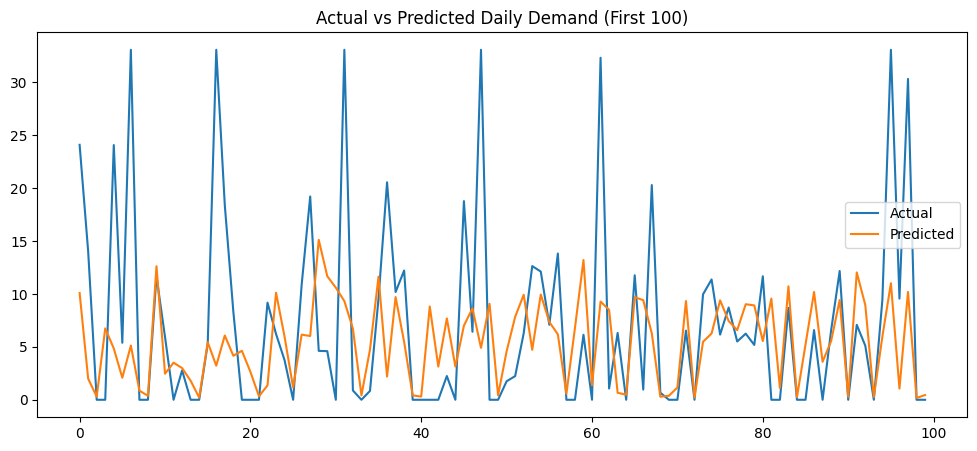

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label="Actual")
plt.plot(pred[:100], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Daily Demand (First 100)")
plt.show()

In [ ]:
print("Daily R2:", r2_score(y_test, pred))

Daily R2: 0.1092992531742043


In [ ]:
import pandas as pd
import numpy as np

def predict_demand(station_id, forecast_date):

    forecast_date = pd.to_datetime(forecast_date)

    # Get historical data for this station
    station_df = daily_data[daily_data["stationID"] == station_id].copy()
    station_df = station_df.sort_values("date")

    if len(station_df) < 14:
        print("Not enough historical data for this station.")
        return None

    # Take last available data BEFORE forecast_date
    station_df = station_df[station_df["date"] < forecast_date]

    if len(station_df) < 5:
        print("Not enough past data before this date.")
        return None

    last_14 = station_df.tail(14)

    lag_1 = last_14["daily_kwh"].iloc[-1]
    lag_7 = last_14["daily_kwh"].iloc[-7]
    lag_14 = last_14["daily_kwh"].iloc[0]

    rolling_7 = last_14["daily_kwh"].tail(7).mean()
    rolling_14 = last_14["daily_kwh"].mean()

    day_of_week = forecast_date.dayofweek
    month = forecast_date.month
    is_weekend = 1 if day_of_week >= 5 else 0

    station_encoded = le.transform([station_id])[0]

    input_data = pd.DataFrame([{
        "station_encoded": station_encoded,
        "lag_1": lag_1,
        "lag_7": lag_7,
        "lag_14": lag_14,
        "rolling_7": rolling_7,
        "rolling_14": rolling_14,
        "day_of_week": day_of_week,
        "month": month,
        "is_weekend": is_weekend
    }])

    # Log prediction
    pred_log = model.predict(input_data)
    prediction = np.expm1(pred_log)[0]

    print("🔋 EV DAILY DEMAND FORECAST")
    print("-----------------------------------")
    print("Station:", station_id)
    print("Forecast Date:", forecast_date.date())
    print("Predicted Demand (kWh):", round(prediction, 2))

    return prediction

In [ ]:
predict_demand(station_id=8, forecast_date="2018-09-01")

Not enough historical data for this station.


In [ ]:
predict_demand(
    station_id=daily_model_df["stationID"].iloc[0],
    forecast_date="2018-10-10"
)

🔋 EV DAILY DEMAND FORECAST
-----------------------------------
Station: 2-39-123-23
Forecast Date: 2018-10-10
Predicted Demand (kWh): 13.01


np.float32(13.012821)

In [125]:
import joblib

joblib.dump(model, "daily_model.pkl")
joblib.dump(le, "station_encoder.pkl")

['station_encoder.pkl']

In [126]:
from google.colab import files

files.download("daily_model.pkl")
files.download("station_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>